# MÓDULO 4 — Fundamentos Estadísticos para el Análisis Predictivo
**Diagnóstico y Predictibilidad | 92-0030 | ULACIT**
**Prof. Robin Sequeira**

---
### INSTRUCCIONES
Este notebook tiene dos partes.

**PARTE 1 (primeros 40 min — hacemos juntos):**
El profesor muestra los conceptos aplicados sobre el Superstore. Ejecuten cada bloque y lean los comentarios. Entienden el qué y el por qué.

**PARTE 2 (45 min en salas de Teams):**
Aplican exactamente los mismos bloques sobre su propio dataset de proyecto. Adaptan el código a sus columnas. Interpretan sus propios resultados.

Al regresar: presentación de 5 minutos por grupo. Este notebook va al Portafolio I (Semana 8).

## PARTE 1 — CON EL PROFESOR (sobre Superstore DS)

### BLOQUE 1 — Carga y primera mirada

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargamos el Superstore como base de demostración.
# En la Parte 2 van a reemplazar esto con su propio dataset.
pdf = spark.table("workspace.diagnosticopredictibilidad.superstore").toPandas()
df = pdf.copy()

print(f"Filas: {df.shape[0]:,}   Columnas: {df.shape[1]}")
print("\nColumnas disponibles:")
print(df.columns.tolist())

Filas: 51,290   Columnas: 25

Columnas disponibles:
['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Region', 'Market', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority', 'Delivery Days', 'order year', 'order month']


### BLOQUE 2 — Estadística descriptiva: el primer diagnóstico
`describe()` resume las variables numéricas en una sola llamada. Es la primera pregunta que le hacemos a cualquier dataset.

**Qué buscar:**
- ¿La media y el 50% (mediana) son muy diferentes? → hay sesgo
- ¿La std es mayor que la media? → datos muy dispersos
- ¿Hay valores negativos donde no deberían existir? → revisar calidad

In [0]:
df.describe().round(2)

# Para Sales: mean ≈ $229, median ≈ $54.
# La media es 4 veces la mediana.
# Unos pocos pedidos grandes están jalando el promedio hacia arriba.
# Eso ya nos dice que no debemos usar la media para imputar nulos.

,Sales,Quantity,Discount,Profit,Shipping Cost,Delivery Days,order year,order month
count,51290.00,51290.00,51290.00,51290.00,51290.00,51290.00,51290.00,51290.00
mean,245.97,3.48,0.14,28.36,25.99,3.97,2013.78,7.52
std,487.56,2.28,0.21,174.19,57.25,1.73,1.10,3.30
min,0.00,1.00,0.00,-6599.00,1.00,0.00,2012.00,1.00
25%,30.00,2.00,0.00,0.00,2.00,3.00,2013.00,5.00
50%,85.00,3.00,0.00,9.00,7.00,4.00,2014.00,8.00
75%,251.00,5.00,0.20,36.00,24.00,5.00,2015.00,10.00
max,22638.00,14.00,0.85,8399.00,933.00,7.00,2015.00,12.00


### BLOQUE 3 — La forma de los datos: histograma
El histograma revela la distribución. Una distribución "normal" tiene forma de campana simétrica. Si la cola está a la derecha, los datos están sesgados → right-skewed.

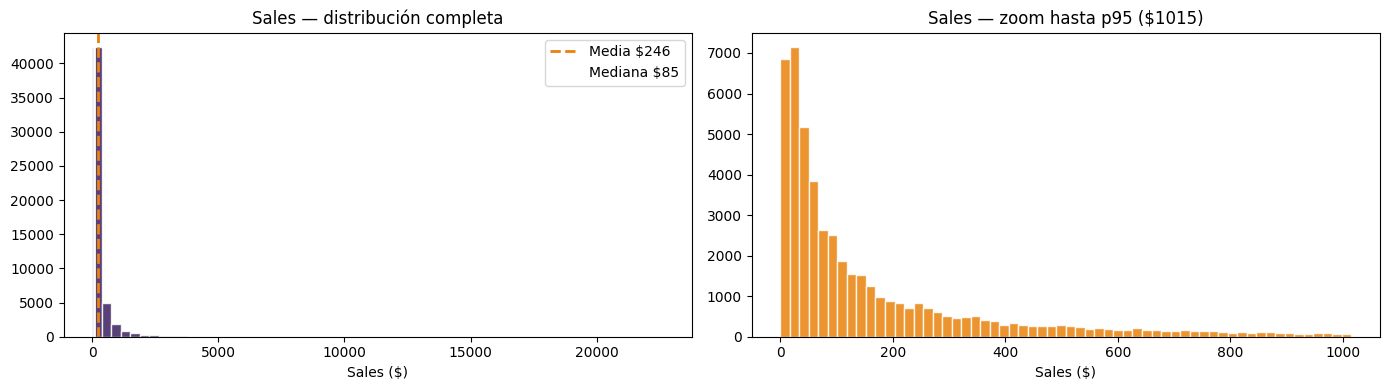

Sesgo (skewness): 8.14


In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Vista completa
axes[0].hist(df['Sales'], bins=60, color='#3B1F5E', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Sales'].mean(),   color='#E8820C', lw=2, ls='--', label=f"Media ${df['Sales'].mean():.0f}")
axes[0].axvline(df['Sales'].median(), color='white',   lw=2, ls='-',  label=f"Mediana ${df['Sales'].median():.0f}")
axes[0].set_title('Sales — distribución completa')
axes[0].set_xlabel('Sales ($)')
axes[0].legend()

# Zoom al 95% para ver mejor el comportamiento típico
p95 = df['Sales'].quantile(0.95)
axes[1].hist(df[df['Sales'] <= p95]['Sales'], bins=60, color='#E8820C', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Sales — zoom hasta p95 (${p95:.0f})')
axes[1].set_xlabel('Sales ($)')

plt.tight_layout()
plt.show()

print(f"Sesgo (skewness): {df['Sales'].skew():.2f}")
# Sesgo > 1 → cola marcada a la derecha.
# Sesgo ≈ 0 → distribución simétrica.
# Sesgo < -1 → cola marcada a la izquierda.

### BLOQUE 4 — Dispersión: varianza y desviación estándar
La media dice dónde está el centro. La desviación estándar dice qué tan lejos pueden estar los datos de ese centro. Alta dispersión = difícil predecir. Baja dispersión = más predecible.

In [0]:
print("Desviación estándar por columna numérica:")
df.select_dtypes(include='number').std().sort_values(ascending=False).round(2)

media = df['Sales'].mean()
std   = df['Sales'].std()
print(f"\nSales: media=${media:.0f}, std=${std:.0f}")
print(f"Rango media ± 1std: [${media-std:.0f}, ${media+std:.0f}]")
# Si el límite inferior es negativo para ventas, los datos
# definitivamente no siguen distribución normal.

Desviación estándar por columna numérica:

Sales: media=$246, std=$488
Rango media ± 1std: [$-242, $734]


### BLOQUE 5 — Correlación entre variables
La correlación mide qué tan relacionadas están dos variables. Rango: -1 (inversa perfecta) a +1 (directa perfecta). 0 = sin relación lineal.

En el Módulo 3 usaron esto para seleccionar variables. Hoy entienden por qué ese criterio tiene sentido estadístico.

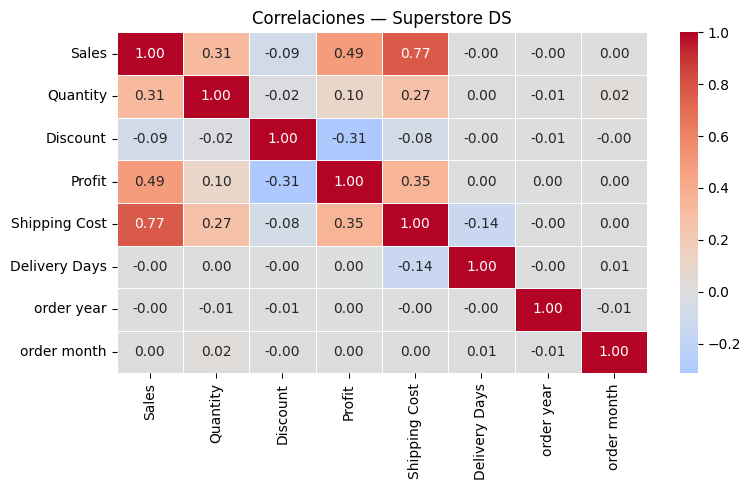

In [0]:
corr = df.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlaciones — Superstore DS')
plt.tight_layout()
plt.show()

# Hallazgos clave:
# Sales  - Profit:   r ≈ +0.48 → positiva moderada
# Discount - Profit: r ≈ -0.22 → negativa débil (más descuento, menos ganancia)
# Discount - Sales:  r ≈ -0.03 → prácticamente nula

### BLOQUE 6 — Prueba de hipótesis: ¿la diferencia es real?
- **H0:** no hay diferencia entre grupos (lo que asumimos por defecto)
- **H1:** sí hay diferencia real (lo que queremos demostrar)

El valor p: si p < 0.05 → rechazamos H0 → diferencia probablemente real. IMPORTANTE: p < 0.05 no dice que la diferencia sea grande o importante.

In [0]:
g1 = df[df['Category'] == 'Technology']['Profit']
g2 = df[df['Category'] == 'Furniture']['Profit']

t_stat, p_val = stats.ttest_ind(g1, g2)

print("Prueba t — Technology vs Furniture (Profit)")
print(f"  Media Technology: ${g1.mean():.2f}")
print(f"  Media Furniture:  ${g2.mean():.2f}")
print(f"  Diferencia:       ${g1.mean() - g2.mean():.2f}")
print(f"  Valor p:          {p_val:.4f}")
if p_val < 0.05:
    print("  → Diferencia estadísticamente significativa.")
else:
    print("  → No hay evidencia suficiente de diferencia.")

Prueba t — Technology vs Furniture (Profit)
  Media Technology: $65.19
  Media Furniture:  $28.73
  Diferencia:       $36.45
  Valor p:          0.0000
  → Diferencia estadísticamente significativa.


## PARTE 2 — ACTIVIDAD EN SALAS DE TEAMS
**Tiempo:** 45 minutos de trabajo + 15 minutos de presentaciones

### INSTRUCCIONES PARA EL GRUPO
Cada grupo aplica el análisis estadístico sobre su propio dataset de proyecto. El que definieron la semana pasada.

Carguen su dataset. Adapten cada bloque a sus columnas. No tienen que copiar el código exacto: ajústenlo a sus datos. Al final preparan 3 a 5 diapositivas (o usan el notebook) para responder las 5 preguntas de la presentación. La presentación no es reportar números. Es interpretar, razonar y conectar con su problema de negocio.

### BLOQUE A — Cargar su dataset
Reemplacen esto con la carga de su propio dataset.

In [0]:
# Si lo tienen en Databricks:
#   mi_df = spark.table("workspace.default.SU_TABLA").toPandas()
# Si lo tienen como CSV:
#   mi_df = pd.read_csv("/ruta/a/su/archivo.csv")

# Ejemplo genérico — cambien por su dataset real:
mi_df = spark.table("workspace.diagnosticopredictibilidad.trainecomerce").toPandas()

print(f"Dataset: {mi_df.shape[0]:,} filas, {mi_df.shape[1]} columnas")
print("\nColumnas:")
print(mi_df.columns.tolist())
print("\nPrimeras filas:")
mi_df.head()

Dataset: 1,460 filas, 81 columnas

Columnas:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3S

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65,8450,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2003,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80,9600,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68,11250,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60,9550,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84,14260,Pave,NA,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NA,NA,NA,0,12,2008,WD,Normal,250000


### BLOQUE B — Estadística descriptiva de su dataset

In [0]:
# Resumen general
print("=== Resumen estadístico ===")
mi_df.describe().round(2)

# Identifiquen sus columnas numéricas clave
# (las que son relevantes para su problema de negocio)
COLUMNA_OBJETIVO = "SalePrice"   # variable objetivo del dataset de casas

print(f"\n=== Análisis de {COLUMNA_OBJETIVO} ===")
print(f"Media:    {mi_df[COLUMNA_OBJETIVO].mean():.2f}")
print(f"Mediana:  {mi_df[COLUMNA_OBJETIVO].median():.2f}")
print(f"Std:      {mi_df[COLUMNA_OBJETIVO].std():.2f}")
print(f"Sesgo:    {mi_df[COLUMNA_OBJETIVO].skew():.2f}")

# Pregunten: ¿la media y la mediana son similares?
# Si no → hay sesgo o valores extremos → eso afecta el modelo.

=== Resumen estadístico ===

=== Análisis de SalePrice ===
Media:    180921.20
Mediana:  163000.00
Std:      79442.50
Sesgo:    1.88


### BLOQUE C — Distribución de la variable principal
Grafiquen la distribución de su variable más importante.

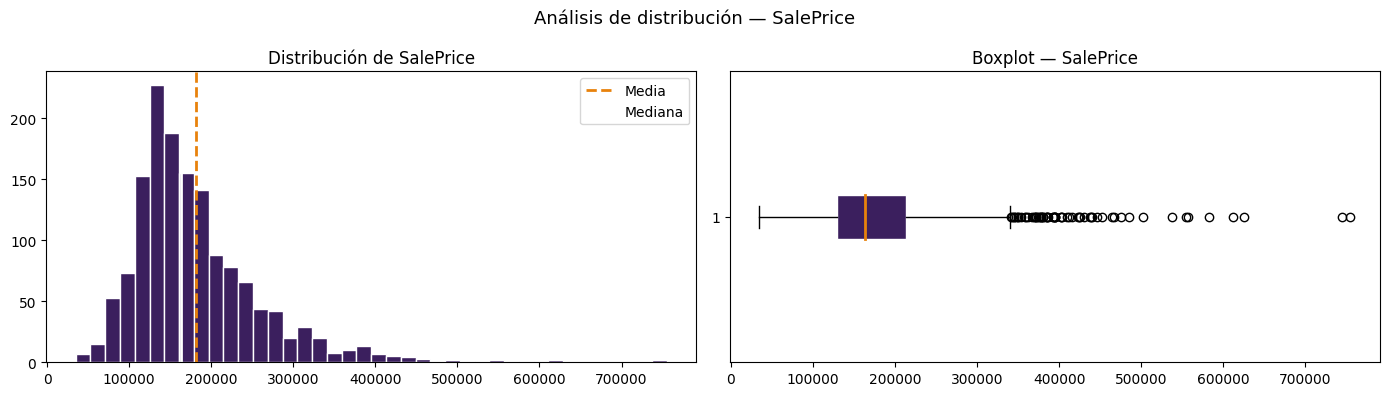

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(mi_df[COLUMNA_OBJETIVO].dropna(), bins=40, color='#3B1F5E', edgecolor='white')
axes[0].axvline(mi_df[COLUMNA_OBJETIVO].mean(),   color='#E8820C', lw=2, ls='--', label='Media')
axes[0].axvline(mi_df[COLUMNA_OBJETIVO].median(), color='white',   lw=2, ls='-',  label='Mediana')
axes[0].set_title(f'Distribución de {COLUMNA_OBJETIVO}')
axes[0].legend()

# Boxplot para visualizar outliers
axes[1].boxplot(mi_df[COLUMNA_OBJETIVO].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3B1F5E', color='white'),
                medianprops=dict(color='#E8820C', linewidth=2))
axes[1].set_title(f'Boxplot — {COLUMNA_OBJETIVO}')

plt.suptitle(f'Análisis de distribución — {COLUMNA_OBJETIVO}', fontsize=13)
plt.tight_layout()
plt.show()

# ¿La distribución se parece a una campana?
# ¿O tiene cola larga? ¿De qué lado?
# Documenten la respuesta en una celda Markdown.

### BLOQUE D — Correlaciones en su dataset
¿Qué variables numéricas están relacionadas entre sí? ¿Cuál tiene mayor relación con su variable objetivo?

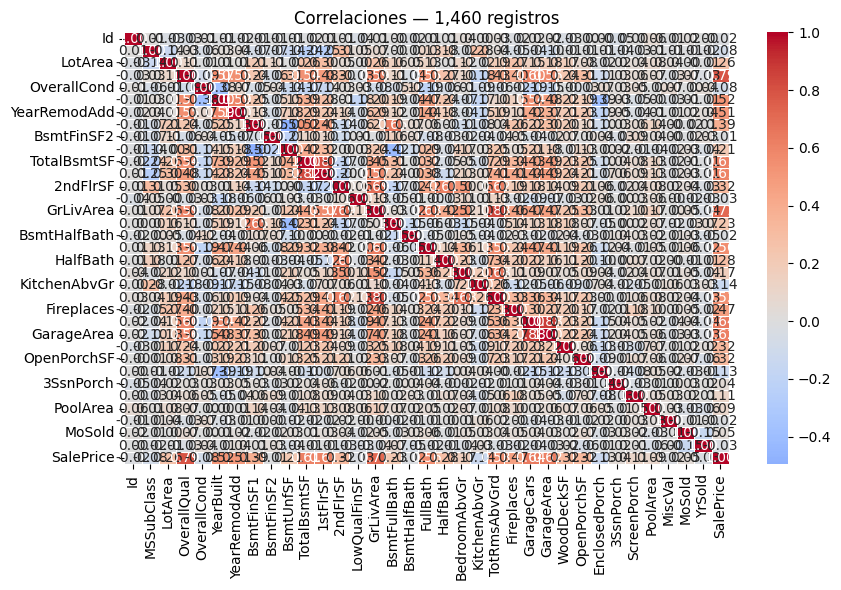


Correlación con SalePrice:
OverallQual      0.791
GrLivArea        0.709
GarageCars       0.640
GarageArea       0.623
TotalBsmtSF      0.614
1stFlrSF         0.606
FullBath         0.561
TotRmsAbvGrd     0.534
YearBuilt        0.523
YearRemodAdd     0.507
Fireplaces       0.467
BsmtFinSF1       0.386
WoodDeckSF       0.324
2ndFlrSF         0.319
OpenPorchSF      0.316
HalfBath         0.284
LotArea          0.264
BsmtFullBath     0.227
BsmtUnfSF        0.214
BedroomAbvGr     0.168
KitchenAbvGr    -0.136
EnclosedPorch   -0.129
ScreenPorch      0.111
PoolArea         0.092
MSSubClass      -0.084
OverallCond     -0.078
MoSold           0.046
3SsnPorch        0.045
YrSold          -0.029
LowQualFinSF    -0.026
Id              -0.022
MiscVal         -0.021
BsmtHalfBath    -0.017
BsmtFinSF2      -0.011
Name: SalePrice, dtype: float64


In [0]:
numericas = mi_df.select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title(f'Correlaciones — {mi_df.shape[0]:,} registros')
plt.tight_layout()
plt.show()

# Tabla de correlación con la variable objetivo
print(f"\nCorrelación con {COLUMNA_OBJETIVO}:")
corr_obj = numericas.corr()[COLUMNA_OBJETIVO].drop(COLUMNA_OBJETIVO)
print(corr_obj.sort_values(key=abs, ascending=False).round(3))

# ¿Hay alguna variable con r > 0.5 o r < -0.5?
# ¿Hay alguna relación que NO esperaban?
# ¿Qué variable tiene más potencial como predictora?

### BLOQUE E — Análisis por segmento (si aplica)
Si su dataset tiene una columna categórica relevante (tipo de cliente, categoría de producto, región, etc.) úsenla para ver si el comportamiento cambia entre grupos.

=== SalePrice por Foundation ===
                 mean    median       std  count
Foundation                                      
BrkTil      132291.08  125250.0  54592.39    146
CBlock      149805.71  141500.0  48295.04    634
PConc       225230.44  205000.0  86865.98    647
Slab        107365.62  104150.0  34213.98     24
Stone       165959.17  126500.0  78557.70      6
Wood        185666.67  164000.0  56695.09      3


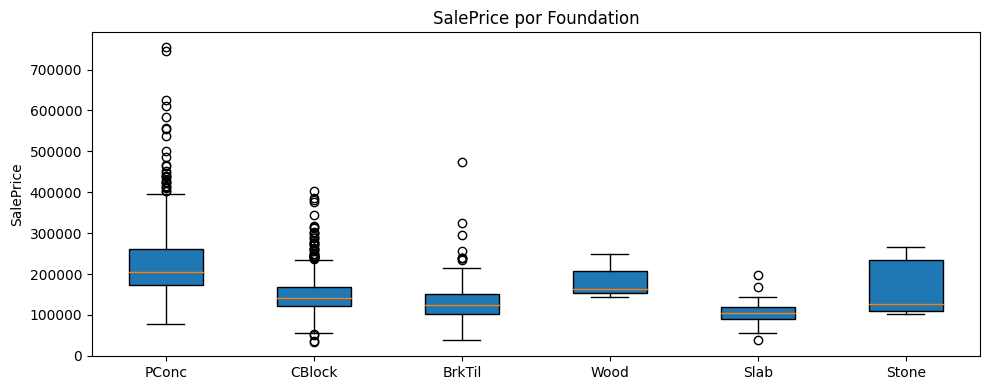

In [0]:
COLUMNA_SEGMENTO = "Foundation"   # cambia esto

print(f"=== {COLUMNA_OBJETIVO} por {COLUMNA_SEGMENTO} ===")
print(mi_df.groupby(COLUMNA_SEGMENTO)[COLUMNA_OBJETIVO]
      .agg(['mean', 'median', 'std', 'count'])
      .round(2))

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 4))
grupos = [mi_df[mi_df[COLUMNA_SEGMENTO] == g][COLUMNA_OBJETIVO].dropna()
          for g in mi_df[COLUMNA_SEGMENTO].unique()]
etiquetas = mi_df[COLUMNA_SEGMENTO].unique().tolist()
ax.boxplot(grupos, labels=etiquetas, patch_artist=True)
ax.set_title(f'{COLUMNA_OBJETIVO} por {COLUMNA_SEGMENTO}')
ax.set_ylabel(COLUMNA_OBJETIVO)
plt.tight_layout()
plt.show()

### BLOQUE F — Prueba de hipótesis sobre sus datos
Elijan dos grupos de su dataset y prueben si la diferencia en la variable objetivo es estadísticamente significativa.

In [0]:
# Ejemplo: ¿el grupo A tiene un valor promedio diferente al grupo B?

GRUPO_A = "PConc"   # ejemplo válido
GRUPO_B = "CBlock"   # ejemplo válido

datos_A = mi_df[mi_df[COLUMNA_SEGMENTO] == GRUPO_A][COLUMNA_OBJETIVO].dropna()
datos_B = mi_df[mi_df[COLUMNA_SEGMENTO] == GRUPO_B][COLUMNA_OBJETIVO].dropna()

t_stat, p_val = stats.ttest_ind(datos_A, datos_B)

sesgo = mi_df['SalePrice'].skew()

print(f"Prueba t — {GRUPO_A} vs {GRUPO_B}")
print(f"  Media {GRUPO_A}: {datos_A.mean():.2f}")
print(f"  Media {GRUPO_B}: {datos_B.mean():.2f}")
print(f"  Diferencia:      {datos_A.mean() - datos_B.mean():.2f}")
print(f"  Valor p:         {p_val:.4f}")
print(f"Sesgo (Skewness):  {sesgo:.4f} (Valores > 1 indican alto sesgo a la derecha)")
print()
if p_val < 0.05:
    print("  → Diferencia estadísticamente significativa (p < 0.05).")
    print("  → Ahora la pregunta importante: ¿es relevante para su negocio?")
else:
    print("  → No hay evidencia suficiente de diferencia real.")
    print("  → Eso también es información: los grupos se comportan igual.")


Prueba t — PConc vs CBlock
  Media PConc: 225230.44
  Media CBlock: 149805.71
  Diferencia:      75424.73
  Valor p:         0.0000
Sesgo (Skewness):  1.8829 (Valores > 1 indican alto sesgo a la derecha)

  → Diferencia estadísticamente significativa (p < 0.05).
  → Ahora la pregunta importante: ¿es relevante para su negocio?


## REFLEXIÓN PARA EL PORTAFOLIO I
**Escriban, de forma honesta:**

1. ¿Qué aprendió su grupo sobre sus propios datos hoy? ¿Hubo algo que no esperaban encontrar?
2. ¿Qué diferencias notaron entre aplicar la estadística sobre el Superstore (datos limpios) y sobre su dataset real trainecomerce?
3. ¿Cómo conecta este análisis estadístico con el Pipeline que construyeron en el Módulo 3?
4. ¿Qué ajuste harían al diseño de su proyecto basados en lo que descubrieron hoy?